## 1 Introduction


*Team members*
- Alexandre Dréan (2408681)
- Julien Segonne (2409827)

In [1]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse as sp
import torch
import torch.nn as nn
from torch.optim import Adam
import scipy.sparse as sp
import numpy as np
from sentence_transformers import SentenceTransformer
import ast
import os
import matplotlib.pyplot as plt

In [11]:
ids = pd.read_csv('data/TP4-ids.csv', index_col=0)
articles = pd.concat([
    pd.read_csv('data/TP4-articles1.csv', index_col=0),
    pd.read_csv('data/TP4-articles2.csv', index_col=0)
], ignore_index=True)
ids_test = pd.read_csv('data/TP4-ids-test.csv', index_col=0)
adjacency = mmread('data/TP4-matrice-adjacence.dgt').tocsr() # Shape : (67294, 67294)

## mise en place de l'ensemble de validation

In [48]:
test = {}
np.random.seed(0)
idx_val_to_del = np.random.randint(1, len(ids), size=500)
adjacency_train = adjacency.copy()
idx_val = []
for idx in idx_val_to_del :
    links = adjacency[idx-1].indices
    if len(links) > 5 :
        to_delete = np.random.choice(links, size=5, replace=False)
        adjacency_train[idx-1, to_delete] = 0
        adjacency_train.eliminate_zeros()
        test[idx] = to_delete
        idx_val.append(idx)


/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [3]:
articles.head()

,id,title,year,authors,abstract
0,58437722ac44360f1082eeb7,Unsupervised Neural Hidden Markov Models.,2016,"[{'_id': '562ce81f45cedb3398cfaa99', 'name': '...","In this work, we present the first results for..."
1,573695ff6e3b12023e513394,Exploring the Limits of Language Modeling.,2016,"[{'_id': '562c7bc245cedb3398c36ee5', 'name': '...",In this work we explore recent advances in Rec...
2,56d81592dabfae2eee6f4c65,A Hierarchical Pitman−Yor Process HMM for Unsu...,2011,"[{'_id': '54480ee0dabfae87b7dce29c', 'name': '...",NaN
3,53e9ad2db7602d97037103c6,Painless unsupervised learning with features,2010,"[{'name': 'Taylor Berg-Kirkpatrick', 'org': 'U...",We show how features can easily be added to st...
4,53e9bd8cb7602d9704a36c0b,Unsupervised part-of-speech tagging with bilin...,2011,"[{'name': 'Dipanjan Das', 'org': 'Carnegie Mel...",We describe a novel approach for inducing unsu...


In [ ]:
# Exemple trouver les articles cités par l'article n=1

n = 1
i = n - 1

cited_indices = adjacency[i].indices
cited_n = cited_indices + 1


cited_ids = ids[ids['n'].isin(cited_n)]['id'].values
cited_articles = articles[articles['id'].isin(cited_ids)][['id', 'title', 'year']]

cited_articles


,id,title,year
1,573695ff6e3b12023e513394,Exploring the Limits of Language Modeling.,2016
2,56d81592dabfae2eee6f4c65,A Hierarchical Pitman−Yor Process HMM for Unsu...,2011
3,53e9ad2db7602d97037103c6,Painless unsupervised learning with features,2010
4,53e9bd8cb7602d9704a36c0b,Unsupervised part-of-speech tagging with bilin...,2011
5,573696da6e3b12023e5d96a9,Labeled Grammar Induction with Minimal Supervi...,2015
6,5736960f6e3b12023e521c63,Recurrent Memory Network for Language Modeling,2016
7,5550401245ce0a409eb3205c,Dropout: a simple way to prevent neural networ...,2014
8,53e9982cb7602d970204e432,Phylogenetic Grammar Induction,2010
9,53e9a645b7602d9702f7362e,Noise-contrastive estimation: A new estimation...,2010
10,573695fd6e3b12023e51147e,Variational Dropout and the Local Reparameteri...,2015


##NDCG

In [7]:
def ndcg(y_true, y_pred, k=20):
    #y_true est la liste des 20 prédictions
    #y_pred est la liste des articles effectivement cités

    dcg = 0.0
    for i, item in enumerate(y_pred):
        if item in y_true:
            rank = i+1
            dcg += 1.0 / np.log2(rank + 1)

    n_relevant = min(len(y_true), k)  #au cas où il y aurait plus de 20 articles cités
    idcg = sum([1.0 / np.log2(i+2) for i in range(n_relevant)])

    if idcg == 0.0:
        return 0.0

    ndcg = dcg / idcg
    return ndcg

## Précision

In [51]:
def precision(y_true, y_pred):
    return len(set(y_pred) & set(y_true))/5

## 2 PageRank algorithm

### 2.1 What is PageRank algorithm and why using it ?
TODO

### 2.2 PageRank code

In [43]:
def pagerank(A, index_init, d=0.85, max_iter=100, tol=1e-6):
    n = A.shape[0]
    r = np.ones(n)/n
    s = np.array(A.sum(axis=1)).flatten()
    inv_s = np.zeros_like(s, dtype=float)
    nonzero = s > 0
    inv_s[nonzero] = 1.0/s[nonzero]  #inversion des valeurs de s

    A = sp.diags(inv_s) @ A   #division de A par s avant la boucle pour ne le faire qu'une fois
    AT = A.tocsc().transpose()  #format optimisé pour la transposition

    teleport = 1-d     #valeur pour la téléportation sur l'index choisi, on ne crée pas de matrice

    for _ in range(max_iter):
        r_new = d * (AT @ r)
        r_new[index_init] += teleport
        #print(r_new.sum())

        #il faut redistribuer la proba manquante, la somme n'est pas toujours égale à 1
        prob = 1.0-r_new.sum()
        if prob > 0:
            r_new[index_init] += prob
        # test de convergence, évite des itérations en trop
        if np.sum(np.abs(r_new - r)) < tol:
            #print(f"Converge après {_ + 1} itérations.")
            break
        r = r_new
    return r

### 2.3 Performances

#~grid search

In [49]:
from tqdm import tqdm

max_iter = 100
tol = 1e-6
d_grid = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9]
ndcg_mean = []
precision_mean = []

for d in d_grid :
    print(f"d = {d}")
    recom = {}
    ndcg_scores = []
    precision_scores = []
    for idx in tqdm(idx_val) :
        r = pagerank(adjacency_train,idx-1,d,max_iter,tol)
        top_indices = r.argsort()[::-1]
        top20 = top_indices[top_indices != idx-1][:20]  #on récupère les top 20 sans l'article initial
        top20 = top20 + 1  #on récupère le vrai indice
        recom[idx] = top20
        ndcg_scores.append(ndcg(test[idx], top20))
        precision_scores.append(precision(test[idx], top20))
    ndcg_mean.append(np.mean(ndcg_scores))
    precision_mean.append(np.mean(precision_scores))




d = 0.1


100%|██████████| 283/283 [00:15<00:00, 18.87it/s]


d = 0.15


100%|██████████| 283/283 [00:15<00:00, 18.03it/s]


d = 0.2


...

100%|██████████| 283/283 [00:27<00:00, 10.48it/s]


d = 0.8


100%|██████████| 283/283 [00:32<00:00,  8.84it/s]


d = 0.9


100%|██████████| 283/283 [00:50<00:00,  5.59it/s]


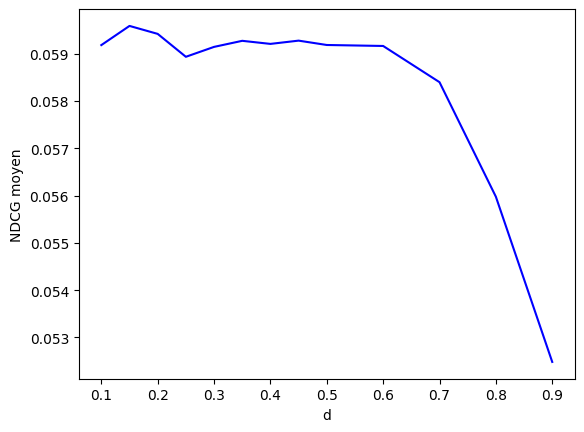

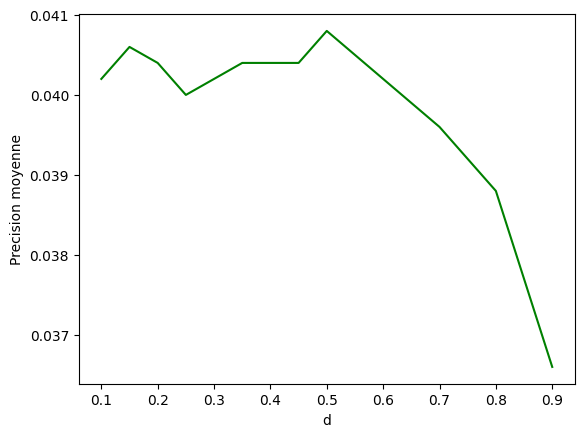

In [30]:
plt.plot(d_grid, ndcg_mean, label='NDCG', color = 'b')
plt.xlabel("d")
plt.ylabel("NDCG moyen")
plt.show()

plt.plot(d_grid, precision_mean, label='Precision', color = 'g')
plt.xlabel("d")
plt.ylabel("Precision moyenne")

plt.show()

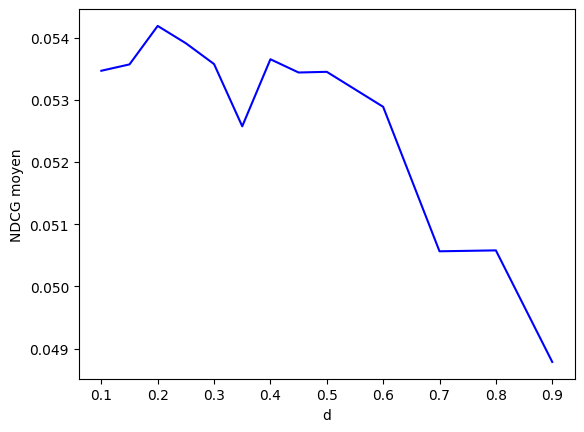

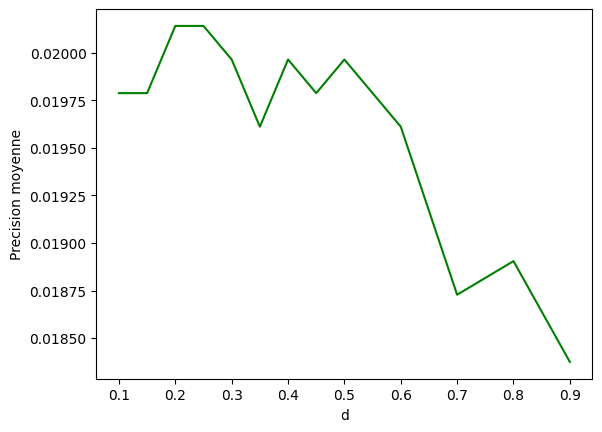

In [50]:
plt.plot(d_grid, ndcg_mean, label='NDCG', color = 'b')
plt.xlabel("d")
plt.ylabel("NDCG moyen")
plt.show()

plt.plot(d_grid, precision_mean, label='Precision', color = 'g')
plt.xlabel("d")
plt.ylabel("Precision moyenne")

plt.show()

In [6]:
# TODO
d = 0.35
max_iter = 100
tol = 1e-6

recom = {}

for idx in ids_test.idx :
    print(f"------ Article {idx} ------")
    r = pagerank(adjacency,idx-1,d,max_iter,tol)
    print(f"somme des probas = {round(r.sum(),2)}")
    top_indices = r.argsort()[::-1]
    top20 = top_indices[top_indices != idx-1][:20]  #on récupère les top 20 sans l'article initial
    top20 = top20 + 1  #on récupère le vrai indice
    print(f"20 recommandations : {top20}")
    indices_recom = ids[ids['n'].isin(top20)]['id'].values
    recom[ids.loc[ids['n'] == idx, 'id'].item()] = " ".join(map(str, indices_recom))

------ Article 34 ------
Convergé après 13 itérations.
somme des probas = 1.0
20 recommandations : [ 105  100  458  460  455  241  435   95  462  461   66  214  332   99
   26  543  546 1910  804 3972]
------ Article 316 ------
Convergé après 12 itérations.
somme des probas = 1.0
20 recommandations : [  308   313   312 18663   310   298   299  1679    15   578 18881   404
   142   318    27 18773   147  1573  1572  2637]
------ Article 469 ------
Convergé après 13 itérations.
somme des probas = 1.0
20 recommandations : [ 1228   851   483   558  3771   521  2362  4032  4036  4035  4034    66
   391 21277   560   473   926   810  7621   814]
------ Article 687 ------
Convergé après 12 itérations.
somme des probas = 1.0
20 recommandations : [   77   498   656  1324   704   294    58 19083  5713  5668   710 18813
  2815  1936  5714   126   116    91  5712   772]
------ Article 738 ------
Convergé après 12 itérations.
somme des probas = 1.0
20 recommandations : [  839   840   397  5959   92

In [7]:
#création du fichier résultats
df = pd.DataFrame(list(recom.items()), columns=['id', 'recommandations'])
df.to_csv("soumissionPR.csv", index=False)

### 2.4 Discussion

TODO

## 3 NGCF algorithm

### 3.1 What is NGCF algorithm and why using it ?

L'algorithme [Neural Graph Collaborative Filtering](./https://arxiv.org/pdf/1905.08108) à pour idée clé de partir du contenu d'un item et d'en faire un embedding, puis cet embedding est enrichi itérativement en parcourant le graphe de relation à partir de cet item. Les informations sémantique contenu dans les relations entre l'item et ces voisins viennent donc enrichir l'information encodé dans l'embedding associé à cet item.

Cela est particulièrement pertinent dans le cadre de cette étude, en effet nous disposons d'informations pertinentes sur les articles en terme de contenu pur (titre, auteurs, abstract), mais le graphe de citation contient aussi des informations supplémentaires pertinentes, étudier les relations connus entre les articles pourrait par exemple permettre d'apprendre que certains auteurs se citent souvent entre sans pour autant être les auteurs avec les publications les plus proches, ce qui n'aurait pas été possible avec le contenu seul.

### 3.2 NGCF Code

In [ ]:
# On commence par créer les embedding qui vont encoder le contenu des articles (titre, auteurs, année, abstract). On peut utiliser un modèle pré-entraîné de type Sentence-BERT pour cela. On utilise allenai-specter (https://arxiv.org/pdf/2004.07180) qui est entraîné spécifiquement sur des articles scientifiques. On concatène le titre et l'abstract pour créer un texte représentatif de chaque article, puis on encode ce texte pour obtenir une matrice d'embeddings initiale E0 de dimension (n_articles, 768).


def parse_authors(authors_str):
    '''Extrait les noms d'auteurs depuis la string de la colonne authors'''
    if pd.isna(authors_str) or authors_str == '':
        return ''
    try:
        authors_list = ast.literal_eval(authors_str)
        names = [a.get('name', '') for a in authors_list if isinstance(a, dict)]
        return ', '.join(names)
    except:
        return ''

def build_text(row):
    title    = '' if pd.isna(row.get('title'))    else str(row['title'])
    year     = '' if pd.isna(row.get('year'))     else str(int(row['year']))
    abstract = '' if pd.isna(row.get('abstract')) else str(row['abstract'])
    authors  = parse_authors(row.get('authors'))

    # Format SPECTER : "titre [SEP] contexte" et on met les auteurs et l'année dans la partie "contexte"
    context = f"{authors} {year} {abstract}".strip()
    return f"{title} [SEP] {context}"



def build_E0_aligned(articles, ids, model_name='allenai-specter'):
    '''
    Construit E0 dans le bon ordre : E0[i] correspond à l'article n=i+1
    '''

    model = SentenceTransformer(model_name)
    n_items = ids['n'].max()

    # Index articles par hex id pour lookup rapide
    articles_indexed = articles.set_index('id')

    texts = []
    missing = 0

    for _, row in ids.sort_values('n').iterrows():
        hex_id = row['id']

        if hex_id in articles_indexed.index:
            article = articles_indexed.loc[hex_id]
            text = build_text(article)
        else:
            text = ''
            missing += 1

        texts.append(text)

    print(f"proportion d'articles non présent dans les fichier articles.csv : {missing}/{n_items}")

    E0 = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # Mettre à zéro les embeddings des articles sans texte
    empty_mask = [t == '' for t in texts]
    E0[empty_mask] = 0.0

    return E0  # shape (67294, embed_size)

In [ ]:
if os.path.exists('E0_specter.npy'):
    E0 = np.load('E0_specter.npy')
    print(f"E0 chargé depuis le cache : {E0.shape}")
else:
    E0 = build_E0_aligned(articles, ids)
    np.save('E0_specter.npy', E0)
    print(f"E0 calculé et sauvegardé : {E0.shape}")

np.save('E0_specter.npy', E0)

E0 chargé depuis le cache : (67294, 768)


In [ ]:
class NGCF_ItemItem(nn.Module):
    def __init__(self, E0, adjacency, n_layers=3, embed_size=256):
        super().__init__()
        n_items = E0.shape[0]
        input_dim  = E0.shape[1] # 768 pour SPECTER -> trop lourd pour ma VRAM je réduis à 256


        self.register_buffer('E0_frozen', torch.tensor(E0, dtype=torch.float32)) # on ne l'optimise pas directement, mais on peut y accéder pour faire de la régularisation L2


        self.proj = nn.Linear(input_dim, embed_size, bias=False)

        # Embedding initial (depuis CLIP/SBERT)
        self.E0 = nn.Parameter(torch.tensor(E0, dtype=torch.float32))

        # Matrices W pour chaque couche
        self.W1 = nn.ModuleList([nn.Linear(embed_size, embed_size, bias=False)
                                  for _ in range(n_layers)])
        self.W2 = nn.ModuleList([nn.Linear(embed_size, embed_size, bias=False)
                                  for _ in range(n_layers)])

        # Si on normalise pas entre les couches les valeurs explosent et ça diverge donc on ajoute une normalisation après chaque couche
        self.norms = nn.ModuleList([nn.LayerNorm(embed_size) for _ in range(n_layers)])


        self.L = self.normalize(adjacency)  # (L = D^-1/2 · A · D^-1/2)
        self.n_layers = n_layers

    def normalize(self, A):
        degrees = np.array(A.sum(axis=1)).flatten()
        D_inv_sqrt = sp.diags(1.0 / np.sqrt(degrees + 1e-8))
        L = D_inv_sqrt @ A @ D_inv_sqrt

        # on garde la matrice creuse pour les perfs
        L_coo = L.tocoo()
        indices = torch.tensor([L_coo.row, L_coo.col], dtype=torch.long)
        values = torch.tensor(L_coo.data, dtype=torch.float32)
        return torch.sparse_coo_tensor(indices, values, L.shape).coalesce()

    def forward(self):


        # on utilise l'autocast pour réduire la précision à float16 et économiser de la VRAM, car les matrices sont grandes et les calculs lourds. Cela peut accélérer l'entraînement sur GPU tout en gardant une précision suffisante pour ce type de tâche.
        # # sparse.mm ne supporte pas float16 sur CUDA donc on fait la propagation en float32 et on cast après
        E = self.proj(self.E0_frozen.float())
        # print(f"  après proj — NaN: {torch.isnan(E).sum()}, min/max: {E.min():.4f}/{E.max():.4f}")
        all_embeddings = [E]
        for l in range(self.n_layers):
            LE = torch.sparse.mm(self.L, E.float())
            LE = nn.functional.normalize(LE, p=2, dim=1)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                # on propage les embeddings à travers le graphe
                # (L+I)E.W1  +  L(E°E).W2
                term1 = self.W1[l](LE + E)           # (L+I)E.W1
                # print(f"  couche {l} term1 — NaN: {torch.isnan(term1).sum()}")
                term2 = self.W2[l](LE * E)            # L(E°E).W2
                # print(f"  couche {l} term2 — NaN: {torch.isnan(term2).sum()}")
                E = nn.functional.leaky_relu(term1 + term2)
                E = self.norms[l](E)
                # print(f"  couche {l} après leakyrelu — NaN: {torch.isnan(E).sum()}, min/max: {E.min():.4f}/{E.max():.4f}")
            all_embeddings.append(E)

        # Concatenation de toutes les couches
        E_concat = torch.cat(all_embeddings, dim=1)
        return E_concat

    def bpr_loss(self, E_concat, i, j, k):
        # i cite j (positif), i ne cite pas k (négatif)
        e_i = E_concat[i]
        e_j = E_concat[j]
        e_k = E_concat[k]

        pos_score = (e_i * e_j).sum(dim=1)
        neg_score = (e_i * e_k).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()
        return loss


def get_training_pairs(adjacency):
    '''
    Extrait toutes les paires (i, j) positives depuis la matrice d'adjacence
    '''
    adjacency_coo = adjacency.tocoo()
    rows = adjacency_coo.row  # articles citants
    cols = adjacency_coo.col  # articles cités
    return rows, cols


def train(model, adjacency, n_epochs=50, batch_size=1024, lr=1e-4, lambda_reg=1e-5, checkpoint_path='checkpoint.pt'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.L = model.L.to(device)

    torch.cuda.empty_cache()
    scaler = torch.amp.GradScaler() # pour gérer l'autocast et éviter les problèmes de sous-flux de gradients en float16
    optimizer = Adam(model.parameters(), lr=lr)


    start_epoch = 0
    loss_history = []
    if os.path.exists(checkpoint_path):
        print(f"Checkpoint trouvé, reprise depuis {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scaler.load_state_dict(checkpoint['scaler_state'])
        start_epoch = checkpoint['epoch'] + 1
        loss_history = checkpoint['loss_history']
        print(f"Reprise à l'epoch {start_epoch + 1}/{n_epochs}")



    # Extraire toutes les paires positives
    rows, cols = get_training_pairs(adjacency)
    n_pairs = len(rows)
    n_items = adjacency.shape[0]

    print(f"Nb paires positives : {n_pairs}")
    print(f"Training sur : {device}")

    for epoch in range(start_epoch, n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")
        model.train()

        # on shuffle les paires à chaque époque
        perm = np.random.permutation(n_pairs)
        rows_shuffled = rows[perm]
        cols_shuffled = cols[perm]

        total_loss = 0
        n_batches = 0
        for start in range(0, n_pairs, batch_size):
            print(f"\rBatch {start//batch_size + 1}/{(n_pairs + batch_size - 1) // batch_size}",end="", flush=True)
            i_batch = rows_shuffled[start:start + batch_size]
            j_batch = cols_shuffled[start:start + batch_size]
            k_batch = np.random.randint(0, n_items, size=len(i_batch)) # quasiment sur que k_batch ne contient pas de paires positives (i, k) car la matrice est très creuse, mais même si c'était le cas ça ne changerait rien à l'entrainement par loi des grands nombres.

            i_t = torch.tensor(i_batch, dtype=torch.long).to(device)
            j_t = torch.tensor(j_batch, dtype=torch.long).to(device)
            k_t = torch.tensor(k_batch, dtype=torch.long).to(device)

            optimizer.zero_grad()
            E_concat = model()

            # print(f"E_concat NaN: {torch.isnan(E_concat).sum()}, Inf: {torch.isinf(E_concat).sum()}")
            # print(f"E_concat min/max: {E_concat.min():.4f} / {E_concat.max():.4f}")


            # BPR loss avec régularisation L2
            loss = model.bpr_loss(E_concat, i_t, j_t, k_t)
            # on régularise plutôt les poids de la projection linéaire que les embeddings initiaux, pour éviter de contraindre trop fortement les embeddings pré-entraînés qui contiennent déjà beaucoup d'information utile
            reg = lambda_reg * model.proj.weight.norm(2).pow(2)
            loss += reg

            # backward et update
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            del E_concat
            torch.cuda.empty_cache()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}")
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scaler_state': scaler.state_dict(),
            'loss': avg_loss,
            'loss_history': loss_history
        }, checkpoint_path)
        print(f"Checkpoint sauvegardé (epoch {epoch+1})")


    return model, loss_history

In [ ]:
model = NGCF_ItemItem(E0, adjacency=adjacency, n_layers=3, embed_size=128)

In [ ]:
model = train(model, adjacency, n_epochs=30, batch_size=2048, lr=1e-4)

Nb paires positives : 621195
Training sur : cuda
Epoch 1/30
Batch 304/304Epoch 1/30 — Loss: 0.1779
Checkpoint sauvegardé (epoch 1)
Epoch 2/30
Batch 304/304Epoch 2/30 — Loss: 0.0877
Checkpoint sauvegardé (epoch 2)
Epoch 3/30
Batch 304/304Epoch 3/30 — Loss: 0.0758
Checkpoint sauvegardé (epoch 3)
Epoch 4/30
Batch 304/304Epoch 4/30 — Loss: 0.0681
Checkpoint sauvegardé (epoch 4)
Epoch 5/30
Batch 196/304

KeyboardInterrupt: 

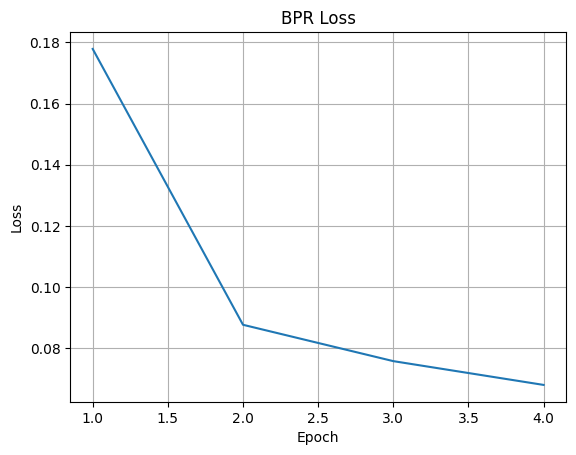

In [ ]:
checkpoint = torch.load('checkpoint.pt')
loss_history = checkpoint['loss_history']
plt.plot(range(1, len(loss_history)+1), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BPR Loss')
plt.grid(True)
plt.show()


In [ ]:
def generate_recommendations(model, test_ids, ids, adjacency, device='cuda', top_k=20):
    '''
    test_ids : DataFrame de test
    ids      : DataFrame de correspondance n <-> id
    '''
    model.eval()
    model = model.to(device)
    model.L = model.L.to(device)

    idx_to_hexid = ids.set_index('n')['id'].to_dict()

    with torch.no_grad():
        E_concat = model()  # (n_items, embed_size * (n_layers+1))

    results = []

    for _, row in test_ids.iterrows():
        hex_id = row['id']
        idx = row['idx']
        i = idx - 1

        scores = (E_concat @ E_concat[i])  # (n_items,)


        # on retire les articles déjà cités par i de la liste de recommandations et l'article lui-même
        known_cited = adjacency.getrow(i).indices
        scores[known_cited] = -float('inf')
        scores[i] = -float('inf')

        # Top 20
        top20_indices = scores.argsort(descending=True)[:top_k].cpu().numpy()

        top20_hexids = [idx_to_hexid[idx + 1] for idx in top20_indices]  # +1 car ids est 1-based

        results.append({
            'id': hex_id,
            'recommandations': ' '.join(top20_hexids)
        })

    return pd.DataFrame(results)

In [ ]:
checkpoint_path = 'checkpoint.pt'

if os.path.exists(checkpoint_path):
    print(f"Checkpoint trouvé, reprise depuis {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cuda')
    model.load_state_dict(checkpoint['model_state'])


test_ids = pd.read_csv('data/TP4-ids-test.csv', index_col=0)
recommendations = generate_recommendations(model, test_ids, ids, adjacency)
recommendations.to_csv('soumissionNGCF.csv', index=False)
print(recommendations.head())




Checkpoint trouvé, reprise depuis checkpoint.pt
torch.Size([67294, 512])
                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9bcd9b7602d97049602cb 56d90157dabfae2eeed96...
1  53e9b7d9b7602d9704389448  53e99e6ab7602d970272ee1b 53e9b857b7602d970441c...
2  53e99e04b7602d97026ca90e  53e9a4c0b7602d9702de31c9 53e9b6bfb7602d9704246...
3  53e9b32bb7602d9703dfdacf  53e99eaeb7602d97027765e8 53e9a97ab7602d97032d1...
4  53e9b9adb7602d970459ef8c  557dbd5fd19faf961d163753 53e9be57b7602d9704b1a...


## 4 Third algorithm

## 5 Fourth algorithm

Mélange entre PR et embeddings de SPECTER

In [4]:
#chargement embeddings
from google.colab import drive
drive.mount('/content/drive')

#emb = pd.read_feather('/content/drive/MyDrive/embeddings.feather')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

# Préparer les embeddings une seule fois hors de la boucle
emb_ids = emb.iloc[:, 0].values
emb_matrix = emb.iloc[:, 1:].values
emb_matrix_norm = normalize(emb_matrix)

# Mappings
id_to_emb_idx = {id_: i for i, id_ in enumerate(emb_ids)}
id_to_graph_idx = {row['id']: row['n'] - 1 for _, row in ids.iterrows()}

# --- Précalcul de toutes les similarités cosinus (nb_test x nb_emb) ---
test_ids_list = ids_test['id'].values
test_emb_indices = [id_to_emb_idx[id_] for id_ in test_ids_list if id_ in id_to_emb_idx]
test_vecs = emb_matrix_norm[test_emb_indices]  # (nb_test, d)

all_cos_sim = cosine_similarity(test_vecs, emb_matrix_norm)  # (nb_test, nb_emb)
print(f"Similarités précalculées : {all_cos_sim.shape}")

# Mapping query_id → ligne dans all_cos_sim
query_id_to_sim_idx = {id_: i for i, id_ in enumerate(test_ids_list) if id_ in id_to_emb_idx}

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [10]:
alpha = 0.15
recommendations = {}
d = 0.35
tol = 1e-7
max_iter = 100

for (idx, id) in ids_test.values:
    print(f"------ Article {idx} ------")

    # --- PPR ---
    r = pagerank(adjacency, idx - 1, d, max_iter, tol)
    r_norm = r / r.sum()

    # --- Récupérer la similarité cosinus précalculée ---
    sim_idx = query_id_to_sim_idx.get(id)

    cos_sim = all_cos_sim[sim_idx]  # (nb_emb,) — déjà calculé

    # Aligner cos_sim vers le graphe
    cos_sim_aligned = np.zeros(adjacency.shape[0])
    for i, eid in enumerate(emb_ids):
        g_idx = id_to_graph_idx.get(eid)
        if g_idx is not None:
            cos_sim_aligned[g_idx] = cos_sim[i]

    # --- Score hybride ---
    score = alpha * r_norm + (1 - alpha) * cos_sim_aligned
    score[idx - 1] = -1

    # --- Top 20 ---
    top20_indices = np.argsort(score)[::-1][:20]
    recommendations[id] = top20_indices + 1
    print(f"  Top 20 (idx graphe) : {top20_indices + 1}")

------ Article 34 ------
Converge après 14 itérations.


NameError: name 'query_id_to_sim_idx' is not defined

In [14]:
# Mapping idx graphe (0-indexé) → string id
graph_idx_to_id = {v: k for k, v in id_to_graph_idx.items()}

# Convertir les idx en string ids
recommendations_ids = {}
for query_id, top20_idx in recommendations.items():
    recommendations_ids[query_id] = [graph_idx_to_id[i - 1] for i in top20_idx]
    # top20_idx est en 1-indexé donc on remet en 0-indexé avec i-1

In [15]:
rows = []
for query_id, top20_ids in recommendations_ids.items():
    recommandations_str = " ".join(top20_ids)  # espace entre ids, pas de virgules ni guillemets
    rows.append({"id": query_id, "recommandations": recommandations_str})

submission = pd.DataFrame(rows)
submission.to_csv("submission.csv", index=False)